# VLM Benchmark — Urban Street Analysis

Compares open-source vision-language models on the Eixample pedestrian comfort + material analysis task.
Each model is loaded, runs inference on `N_TEST_IMAGES` Street View images, then unloaded before the next model loads.

## Models
| Name | HF Model ID | Est. VRAM |
|---|---|---|
| Qwen2.5-VL-3B | `Qwen/Qwen2.5-VL-3B-Instruct` | ~8 GB |
| Qwen2.5-VL-7B | `Qwen/Qwen2.5-VL-7B-Instruct` | ~16 GB |
| InternVL2.5-8B | `OpenGVLab/InternVL2_5-8B` | ~18 GB |
| Llama-3.2-11B-Vision | `meta-llama/Llama-3.2-11B-Vision-Instruct` | ~22 GB |
| Phi-3.5-Vision | `microsoft/Phi-3.5-vision-instruct` | ~10 GB |

## Metrics
| Metric | Description |
|---|---|
| `parse_ok` | JSON was successfully decoded from the model output |
| `echo_detected` | Model echoed the prompt template instead of analysing the image |
| `pop_rate` | Fraction of the 23 fields populated with non-`unknown` content |
| `latency_ms` | Wall-clock inference time per image |
| `peak_vram_gb` | Peak GPU memory allocated during inference |

In [1]:
import subprocess, sys

PACKAGES = [
    "accelerate>=0.30",
    "pandas",
    "matplotlib",
    "seaborn",
    "Pillow",
    "pydantic",
    "python-dotenv",
    "tqdm",
    "torchvision",
    "einops",        # required by InternVL2.5 remote code
    "timm",          # required by InternVL2.5 remote code
    "sentencepiece", # required by InternVL2.5 tokenizer
]
for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies ready")

Dependencies ready


In [2]:
import gc, json, re, time, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode
from PIL import Image
from pydantic import BaseModel, field_validator, FieldValidationInfo
from typing import Any
from dotenv import load_dotenv
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
load_dotenv()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}  ({props.total_memory/1e9:.1f} GB VRAM)")

Device : cuda
GPU    : NVIDIA L4  (23.7 GB VRAM)


/tmp/ipykernel_617527/582139239.py:12: PydanticDeprecatedSince20: Importing FieldValidationInfo from `pydantic` is deprecated. This feature is either no longer supported, or is not public. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  from pydantic import BaseModel, field_validator, FieldValidationInfo


In [3]:
# ── Auth ──────────────────────────────────────────────────────────────────────
HF_TOKEN = os.environ.get("HF_TOKEN", "")
assert HF_TOKEN, "Set HF_TOKEN in .env or as environment variable"

# ── Images ────────────────────────────────────────────────────────────────────
TEST_IMAGES_DIR = Path(os.environ.get("TEST_IMAGES_DIR", "../StreetPLM/images"))
N_TEST_IMAGES   = 3
MAX_NEW_TOKENS  = 2500

# ── Models ────────────────────────────────────────────────────────────────────
MODELS = [
    dict(name="Qwen2.5-VL-3B",  model_id="Qwen/Qwen2.5-VL-3B-Instruct",
         adapter="qwen25vl",    vram_gb=8,  skip=False,
         note="Lightweight baseline; fits 8 GB VRAM"),
    dict(name="Qwen2.5-VL-7B",  model_id="Qwen/Qwen2.5-VL-7B-Instruct",
         adapter="qwen25vl",    vram_gb=16, skip=False,
         note="Recommended — best JSON discipline and field coverage"),
    dict(name="InternVL2.5-8B", model_id="OpenGVLab/InternVL2_5-8B",
         adapter="internvl",    vram_gb=18, skip=False,
         note="Strong spatial & material understanding; trust_remote_code"),
    dict(name="PLM-8B",         model_id="facebook/Perception-LM-8B",
         adapter="plm8b",       vram_gb=16, skip=False,
         note="Meta perception model — strong bbox grounding; not EU-blocked unlike Llama"),
    dict(name="Phi-3.5-Vision", model_id="microsoft/Phi-3.5-vision-instruct",
         adapter="phi35vision", vram_gb=10, skip=False,
         note="Efficient 4.2B; good at structured output"),
]

print(f"Models to benchmark: {[m['name'] for m in MODELS if not m['skip']]}")

Models to benchmark: ['Qwen2.5-VL-3B', 'Qwen2.5-VL-7B', 'InternVL2.5-8B', 'PLM-8B', 'Phi-3.5-Vision']


In [ ]:
# ── Schema + Prompt + Parsing  (kept in sync with street_plm_job.py) ──────────

_QUADRANT_KEYS = ("top_left", "top_right", "bottom_left", "bottom_right")

class StreetSceneAnalysis(BaseModel):
    scene_context           : Any = "unknown"
    perceived_safety        : str = "unknown"
    visibility              : str = "unknown"
    lighting_quality        : str = "unknown"
    cleanliness             : str = "unknown"
    greenery                : str = "unknown"
    thermal_comfort         : str = "unknown"
    walkability             : str = "unknown"
    noise_comfort           : str = "unknown"
    crowding                : str = "unknown"
    privacy                 : str = "unknown"
    social_potential        : str = "unknown"
    visual_interest         : str = "unknown"
    enclosure_exposure      : str = "unknown"
    accessibility           : str = "unknown"
    street_activity         : str = "unknown"
    facade_materials        : str = "unknown"
    ground_surface_material : str = "unknown"
    seating                 : str = "unknown"
    street_furniture        : str = "unknown"
    active_frontage         : str = "unknown"
    architectural_style     : str = "unknown"
    facade_articulation     : str = "unknown"

    @field_validator("*", mode="before")
    @classmethod
    def _coerce(cls, v, info: FieldValidationInfo):
        if info.field_name == "scene_context":
            if isinstance(v, dict):
                return {qk: str(v.get(qk, "unknown")).strip() or "unknown" for qk in _QUADRANT_KEYS}
            s = str(v).strip() if v else "unknown"
            return s or "unknown"
        if isinstance(v, list):
            # List values belong to bbox fields — don't stringify them here
            return ", ".join(str(x).strip() for x in v if str(x).strip()) or "unknown"
        if isinstance(v, dict):
            return str(v)
        s = str(v).strip() if v else "unknown"
        return s if s else "unknown"

ALL_FIELDS   = list(StreetSceneAnalysis.model_fields.keys())  # 23 fields incl scene_context
TEXT_FIELDS  = [f for f in ALL_FIELDS if f != "scene_context"]  # 22 flat string fields
BBOX_FIELDS  = [f + "_bbox" for f in TEXT_FIELDS]               # 22 companion bbox keys
print(f"Schema: {len(ALL_FIELDS)} desc fields  |  {len(BBOX_FIELDS)} bbox fields")

# ── Key aliases ───────────────────────────────────────────────────────────────
_KEY_ALIASES = {
    "scene_context": "scene_context", "scene context": "scene_context", "scene": "scene_context",
    "perceived_safety": "perceived_safety", "safety": "perceived_safety", "security": "perceived_safety",
    "visibility": "visibility", "sightlines": "visibility", "visual clarity": "visibility",
    "lighting_quality": "lighting_quality", "lighting": "lighting_quality", "illumination": "lighting_quality",
    "cleanliness": "cleanliness", "litter": "cleanliness", "maintenance": "cleanliness",
    "greenery": "greenery", "vegetation": "greenery", "green": "greenery",
    "thermal_comfort": "thermal_comfort", "thermal comfort": "thermal_comfort", "shade": "thermal_comfort",
    "walkability": "walkability", "walking": "walkability", "pavement quality": "walkability",
    "noise_comfort": "noise_comfort", "noise comfort": "noise_comfort", "noise": "noise_comfort",
    "crowding": "crowding", "density": "crowding", "crowd": "crowding",
    "privacy": "privacy", "exposure": "privacy", "overlooking": "privacy",
    "social_potential": "social_potential", "social potential": "social_potential", "social": "social_potential",
    "visual_interest": "visual_interest", "visual interest": "visual_interest", "interest": "visual_interest",
    "enclosure_exposure": "enclosure_exposure", "enclosure exposure": "enclosure_exposure", "enclosure": "enclosure_exposure",
    "accessibility": "accessibility", "access": "accessibility",
    "street_activity": "street_activity", "street activity": "street_activity", "activity": "street_activity",
    "facade_materials": "facade_materials", "facade materials": "facade_materials", "materials": "facade_materials", "cladding": "facade_materials",
    "ground_surface_material": "ground_surface_material", "ground surface material": "ground_surface_material",
    "pavement material": "ground_surface_material", "pavement": "ground_surface_material", "paving": "ground_surface_material",
    "seating": "seating", "seats": "seating", "benches": "seating",
    "street_furniture": "street_furniture", "street furniture": "street_furniture", "furniture": "street_furniture",
    "active_frontage": "active_frontage", "active frontage": "active_frontage", "frontage": "active_frontage",
    "architectural_style": "architectural_style", "architectural style": "architectural_style",
    "architecture": "architectural_style", "style": "architectural_style", "period": "architectural_style",
    "facade_articulation": "facade_articulation", "facade articulation": "facade_articulation",
    "facade detail": "facade_articulation", "ornamentation": "facade_articulation",
}

# ── Prompt (synced with street_plm_job.py — includes bbox instructions) ──────
_SCENE_PROMPT = (
    "You are an urban comfort analyst. Study this street-view photo from Barcelona carefully.\n"
    "\n"
    "Assess how comfortable, safe, and pleasant this specific street feels for a pedestrian.\n"
    "Cover both perceptual comfort qualities AND visual/material characteristics of the built fabric.\n"
    "Write 1-2 sentences per description field describing what you actually observe.\n"
    "\n"
    "BOUNDING BOXES: The image is 640x640 pixels. Origin (0,0) is top-left; x increases right, y increases down.\n"
    "For every description field, output a companion key ending in \"_bbox\": [x1, y1, x2, y2]\n"
    "(four integers) enclosing the image area where that feature is most visible.\n"
    "Use [0, 0, 640, 640] only when the feature is distributed across the entire scene.\n"
    "\n"
    "Return ONLY a valid JSON object. Replace every placeholder with your real observations:\n"
    "{\n"
    '  "scene_context": {\n'
    '    "top_left":     "describe top-left quadrant",\n'
    '    "top_right":    "describe top-right quadrant",\n'
    '    "bottom_left":  "describe bottom-left area",\n'
    '    "bottom_right": "describe bottom-right area"\n'
    '  },\n'
    '  "perceived_safety":              "your safety observation",\n'
    '  "perceived_safety_bbox":         [0, 0, 640, 640],\n'
    '  "visibility":                    "your visibility observation",\n'
    '  "visibility_bbox":               [0, 0, 640, 640],\n'
    '  "lighting_quality":              "your lighting observation",\n'
    '  "lighting_quality_bbox":         [0, 0, 640, 640],\n'
    '  "cleanliness":                   "your cleanliness observation",\n'
    '  "cleanliness_bbox":              [0, 0, 640, 640],\n'
    '  "greenery":                      "your greenery observation",\n'
    '  "greenery_bbox":                 [0, 0, 640, 640],\n'
    '  "thermal_comfort":               "your thermal comfort observation",\n'
    '  "thermal_comfort_bbox":          [0, 0, 640, 640],\n'
    '  "walkability":                   "your walkability observation",\n'
    '  "walkability_bbox":              [0, 0, 640, 640],\n'
    '  "noise_comfort":                 "your noise observation",\n'
    '  "noise_comfort_bbox":            [0, 0, 640, 640],\n'
    '  "crowding":                      "your crowding observation",\n'
    '  "crowding_bbox":                 [0, 0, 640, 640],\n'
    '  "privacy":                       "your privacy observation",\n'
    '  "privacy_bbox":                  [0, 0, 640, 640],\n'
    '  "social_potential":              "your social potential observation",\n'
    '  "social_potential_bbox":         [0, 0, 640, 640],\n'
    '  "visual_interest":               "your visual interest observation",\n'
    '  "visual_interest_bbox":          [0, 0, 640, 640],\n'
    '  "enclosure_exposure":            "your enclosure observation",\n'
    '  "enclosure_exposure_bbox":       [0, 0, 640, 640],\n'
    '  "accessibility":                 "your accessibility observation",\n'
    '  "accessibility_bbox":            [0, 0, 640, 640],\n'
    '  "street_activity":               "your street activity observation",\n'
    '  "street_activity_bbox":          [0, 0, 640, 640],\n'
    '  "facade_materials":              "your facade materials observation",\n'
    '  "facade_materials_bbox":         [0, 0, 640, 640],\n'
    '  "ground_surface_material":       "your pavement material observation",\n'
    '  "ground_surface_material_bbox":  [0, 0, 640, 640],\n'
    '  "seating":                       "your seating observation",\n'
    '  "seating_bbox":                  [0, 0, 640, 640],\n'
    '  "street_furniture":              "your street furniture observation",\n'
    '  "street_furniture_bbox":         [0, 0, 640, 640],\n'
    '  "active_frontage":               "your active frontage observation",\n'
    '  "active_frontage_bbox":          [0, 0, 640, 640],\n'
    '  "architectural_style":           "your architectural style observation",\n'
    '  "architectural_style_bbox":      [0, 0, 640, 640],\n'
    '  "facade_articulation":           "your facade detail observation",\n'
    '  "facade_articulation_bbox":      [0, 0, 640, 640]\n'
    "}\n"
    "\n"
    "Output only the JSON object. No other text."
)

# ── Echo sentinels ────────────────────────────────────────────────────────────
_ECHO_SENTINELS = frozenset({
    "your safety observation", "your visibility observation",
    "your lighting observation", "your cleanliness observation",
    "your greenery observation", "your thermal comfort observation",
    "your walkability observation", "your noise observation",
    "your crowding observation", "your privacy observation",
    "your social potential observation", "your visual interest observation",
    "your enclosure observation", "your accessibility observation",
    "your street activity observation",
    "your facade materials observation", "your pavement material observation",
    "your seating observation", "your street furniture observation",
    "your active frontage observation", "your architectural style observation",
    "your facade detail observation",
    "describe top-left quadrant", "describe top-right quadrant",
    "describe bottom-left area", "describe bottom-right area",
})

# ── Parse helpers ─────────────────────────────────────────────────────────────
def _validate_bbox(v, img_size=640):
    """Validate and clamp a bbox. Returns [x1,y1,x2,y2] or None."""
    try:
        if not isinstance(v, (list, tuple)) or len(v) != 4:
            return None
        x1, y1, x2, y2 = (max(0, min(img_size, int(c))) for c in v)
        return [x1, y1, x2, y2] if x2 > x1 and y2 > y1 else None
    except (ValueError, TypeError):
        return None

def _model_echoed_template(parsed: dict) -> bool:
    for v in parsed.values():
        if isinstance(v, str) and v.lower() in _ECHO_SENTINELS:
            return True
        if isinstance(v, dict):
            for sv in v.values():
                if isinstance(sv, str) and sv.lower() in _ECHO_SENTINELS:
                    return True
    return False

def _normalise_result(raw: dict) -> dict:
    flat = {}
    for k, v in raw.items():
        canonical_k = _KEY_ALIASES.get(k.strip().lower(), "")
        if canonical_k == "scene_context":
            flat["scene_context"] = v
        elif isinstance(v, dict) and canonical_k != "scene_context":
            flat.update(v)
        else:
            flat[k] = v
    normalised = {}
    for k, v in flat.items():
        canonical = _KEY_ALIASES.get(k.strip().lower())
        if canonical:
            normalised[canonical] = v
        elif k == "scene_context":
            normalised["scene_context"] = v
    try:
        return StreetSceneAnalysis(**normalised).model_dump()
    except Exception:
        return StreetSceneAnalysis().model_dump()

def _parse_scene_json(text: str) -> tuple:
    """Returns (desc_dict, bbox_dict, parse_ok, echo_detected).

    desc_dict : validated StreetSceneAnalysis fields (strings).
    bbox_dict : {field_bbox: [x1,y1,x2,y2]} for every valid bbox found.
    """
    candidate = None
    for attempt in (text, text + "}"):
        try:
            candidate = json.loads(attempt); break
        except json.JSONDecodeError:
            pass
    if candidate is None:
        m = re.search(r"\{[\s\S]*\}", text)
        if m:
            try: candidate = json.loads(m.group())
            except json.JSONDecodeError: pass
    if candidate is None and "{" in text:
        truncated = text.strip().rstrip(",")
        opens = truncated.count("{") - truncated.count("}")
        if opens > 0:
            try: candidate = json.loads(truncated + "}" * opens)
            except json.JSONDecodeError: pass
        if candidate is None:
            stripped = re.sub(r',\s*"[^"]*$', "", truncated)
            opens2 = stripped.count("{") - stripped.count("}")
            if opens2 >= 0:
                try: candidate = json.loads(stripped + "}" * opens2)
                except json.JSONDecodeError: pass
    if candidate is None:
        # Regex fallback — only recovers string fields, bboxes lost
        pairs = {m.group(1): m.group(2) for m in re.finditer(r'"([^"]+)"\s*:\s*"([^"]*)"', text)}
        if pairs: candidate = pairs

    if not candidate or not isinstance(candidate, dict):
        return StreetSceneAnalysis().model_dump(), {}, False, False

    # Separate bbox keys (arrays) from description keys (strings/dicts)
    raw_bboxes = {}
    raw_descs  = {}
    for k, v in candidate.items():
        if k.endswith("_bbox"):
            validated = _validate_bbox(v)
            if validated is not None:
                raw_bboxes[k] = validated
        else:
            raw_descs[k] = v

    echo = _model_echoed_template(raw_descs)
    if echo:
        return StreetSceneAnalysis().model_dump(), {}, True, True

    return _normalise_result(raw_descs), raw_bboxes, True, False

print("Schema, prompt, and parser loaded")

In [5]:
# ── VRAM utilities ────────────────────────────────────────────────────────────

def reset_vram_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def get_peak_vram_gb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1e9

def free_model(*objs):
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

print("VRAM helpers ready")

VRAM helpers ready


In [ ]:
# ── Model adapters ────────────────────────────────────────────────────────────
# Each adapter exposes: load(), infer(pil_image) -> str, unload()

DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
MAX_PIXELS = (784 * 28 * 28) if DEVICE == "cuda" else (256 * 28 * 28)


class Qwen25VLAdapter:
    """Qwen/Qwen2.5-VL-3B-Instruct and Qwen/Qwen2.5-VL-7B-Instruct."""

    def load(self, model_id, hf_token):
        from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
        self.processor = AutoProcessor.from_pretrained(
            model_id, token=hf_token, use_fast=True,
            min_pixels=256 * 28 * 28, max_pixels=MAX_PIXELS,
        )
        self.model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_id, token=hf_token, torch_dtype=DTYPE,
            device_map=DEVICE, low_cpu_mem_usage=True,
        ).eval()

    def infer(self, pil_image: Image.Image) -> str:
        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": _SCENE_PROMPT}]}]
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True) + "{"
        inputs = self.processor(text=[text], images=[pil_image], padding=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            gen = self.model.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS,
                eos_token_id=self.processor.tokenizer.eos_token_id,
                pad_token_id=self.processor.tokenizer.pad_token_id,
                repetition_penalty=1.1,
            )
        new_ids = gen[:, inputs["input_ids"].shape[1]:]
        return "{" + self.processor.tokenizer.batch_decode(new_ids, skip_special_tokens=True)[0]

    def unload(self):
        free_model(self.model, self.processor)


class InternVL25Adapter:
    """OpenGVLab/InternVL2_5-8B.

    Hides CUDA during from_pretrained so InternVL's custom __init__ code cannot
    trigger accelerate's init_empty_weights() meta-device path.
    """

    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD  = (0.229, 0.224, 0.225)

    def _build_transform(self, size=448):
        return T.Compose([
            T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
            T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
            T.ToTensor(),
            T.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
        ])

    def load(self, model_id, hf_token):
        from transformers import AutoConfig, AutoTokenizer, AutoModel
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_id, token=hf_token, trust_remote_code=True, use_fast=False,
        )
        config = AutoConfig.from_pretrained(model_id, token=hf_token, trust_remote_code=True)
        config.use_flash_attn = False
        if hasattr(config, "llm_config"):
            config.llm_config._attn_implementation        = "eager"
            config.llm_config._attn_implementation_autoset = False

        old_cuda = os.environ.get("CUDA_VISIBLE_DEVICES")
        os.environ["CUDA_VISIBLE_DEVICES"] = ""
        try:
            self.model = AutoModel.from_pretrained(
                model_id, token=hf_token, config=config,
                torch_dtype=DTYPE, trust_remote_code=True,
            )
        finally:
            if old_cuda is None:
                os.environ.pop("CUDA_VISIBLE_DEVICES", None)
            else:
                os.environ["CUDA_VISIBLE_DEVICES"] = old_cuda

        self.model = self.model.to(DEVICE).eval()
        self.transform = self._build_transform()

    def infer(self, pil_image: Image.Image) -> str:
        pixel_values = self.transform(pil_image).unsqueeze(0).to(DEVICE, dtype=DTYPE)
        generation_config = dict(max_new_tokens=MAX_NEW_TOKENS, do_sample=False, repetition_penalty=1.1)
        prompt = f"<image>\n{_SCENE_PROMPT}\n{{"
        response = self.model.chat(
            self.tokenizer, pixel_values, prompt, generation_config,
            history=None, return_history=False,
        )
        return "{" + response if not response.startswith("{") else response

    def unload(self):
        free_model(self.model, self.tokenizer)


class PLM8BAdapter:
    """facebook/Perception-LM-8B.

    PLM checkpoints omit lm_head.weight from the saved state.  It must be tied
    to the language model's embed_tokens weight manually.  We try two common
    path variants — one for PLM-1B and one for PLM-8B — so the bridge is robust
    to architecture differences between the two model sizes.
    """

    # Possible paths to embed_tokens.weight across PLM variants
    _EMBED_PATHS = [
        "model.language_model.embed_tokens.weight",       # PLM-8B (Llama-3.1-8B base)
        "model.language_model.model.embed_tokens.weight", # alternative Llama-3.1 layout
        "model.model.language_model.embed_tokens.weight",  # PLM-1B layout
    ]

    def _tie_lm_head(self):
        for path in self._EMBED_PATHS:
            try:
                obj = self.model
                for attr in path.split("."):
                    obj = getattr(obj, attr)
                self.model.lm_head.weight = obj
                print(f"    lm_head tied via: {path}")
                return
            except AttributeError:
                continue
        print("    WARNING: could not tie lm_head.weight — no matching embed_tokens path found")

    def load(self, model_id, hf_token):
        from transformers import AutoModelForImageTextToText, AutoProcessor
        self.processor = AutoProcessor.from_pretrained(
            model_id, token=hf_token, use_fast=True,
        )
        if hasattr(self.processor, "image_processor") and \
                hasattr(self.processor.image_processor, "max_num_tiles"):
            vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if DEVICE == "cuda" else 0
            self.processor.image_processor.max_num_tiles = 4 if vram_gb >= 20 else 2

        self.model = AutoModelForImageTextToText.from_pretrained(
            model_id, token=hf_token, torch_dtype=DTYPE,
            device_map=DEVICE, low_cpu_mem_usage=True,
        )
        self._tie_lm_head()
        self.model.eval()

    def infer(self, pil_image: Image.Image) -> str:
        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": _SCENE_PROMPT}]}]
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True) + "{"
        inputs = self.processor(images=pil_image, text=text, return_tensors="pt")
        for k, v in list(inputs.items()):
            if hasattr(v, "to"):
                inputs[k] = v.to(DEVICE, dtype=DTYPE) if v.is_floating_point() else v.to(DEVICE)
        with torch.no_grad():
            gen = self.model.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS,
                eos_token_id=self.processor.tokenizer.eos_token_id,
                pad_token_id=self.processor.tokenizer.pad_token_id,
                repetition_penalty=1.1,
            )
        new_ids = gen[:, inputs["input_ids"].shape[1]:]
        return "{" + self.processor.tokenizer.batch_decode(new_ids, skip_special_tokens=True)[0]

    def unload(self):
        free_model(self.model, self.processor)


class Phi35VisionAdapter:
    """microsoft/Phi-3.5-vision-instruct."""

    def load(self, model_id, hf_token):
        from transformers import AutoConfig, AutoModelForCausalLM, AutoProcessor
        self.processor = AutoProcessor.from_pretrained(
            model_id, token=hf_token, trust_remote_code=True,
            num_crops=4, use_fast=False,
        )
        config = AutoConfig.from_pretrained(model_id, token=hf_token, trust_remote_code=True)
        config._attn_implementation         = "eager"
        config._attn_implementation_autoset = False
        if hasattr(config, "use_flash_attention_2"):
            config.use_flash_attention_2 = False
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id, token=hf_token, config=config,
            torch_dtype=DTYPE, device_map="auto",
            trust_remote_code=True, low_cpu_mem_usage=True,
        ).eval()

    def infer(self, pil_image: Image.Image) -> str:
        try:
            from transformers.cache_utils import DynamicCache
            if not hasattr(DynamicCache, "seen_tokens"):
                def _seen_tokens(self):
                    if hasattr(self, "_seen_tokens"):
                        return self._seen_tokens
                    try:
                        return self.key_cache[0].shape[-2]
                    except (AttributeError, IndexError):
                        return 0
                DynamicCache.seen_tokens = property(_seen_tokens)
        except Exception:
            pass

        messages = [{"role": "user", "content": f"<|image_1|>\n{_SCENE_PROMPT}"}]
        prompt = self.processor.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        ) + "{"
        inputs = self.processor(prompt, [pil_image], return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            gen = self.model.generate(
                **inputs, max_new_tokens=MAX_NEW_TOKENS,
                eos_token_id=self.processor.tokenizer.eos_token_id,
                repetition_penalty=1.1,
            )
        new_ids = gen[:, inputs["input_ids"].shape[1]:]
        return "{" + self.processor.batch_decode(new_ids, skip_special_tokens=True)[0]

    def unload(self):
        free_model(self.model, self.processor)


_ADAPTER_MAP = {
    "qwen25vl":   Qwen25VLAdapter,
    "internvl":   InternVL25Adapter,
    "plm8b":      PLM8BAdapter,
    "phi35vision": Phi35VisionAdapter,
}

print("Model adapters defined")

In [7]:
# ── Test image loader ─────────────────────────────────────────────────────────
# Primary source: existing Street View JPGs produced by street_plm_job.py.
# Fallback: fetches Street View images directly from known Eixample locations
# using the same GOOGLE_STREETVIEW_API_KEY already in the environment.

import urllib.request
import io

STREETVIEW_API_KEY = os.environ.get("GOOGLE_STREETVIEW_API_KEY", "")

_SV_BASE  = "https://maps.googleapis.com/maps/api/streetview"
_META_BASE = "https://maps.googleapis.com/maps/api/streetview/metadata"

# 3 representative Eixample points (Passeig de Gràcia, Enric Granados, Gran Via)
_FALLBACK_POINTS = [
    dict(lat=41.3952, lon=2.1617, heading=0,   label="passeig_de_gracia"),
    dict(lat=41.3930, lon=2.1628, heading=90,  label="enric_granados"),
    dict(lat=41.3872, lon=2.1700, heading=180, label="gran_via"),
]

def _fetch_sv_image(lat: float, lon: float, heading: float, size="640x640") -> Image.Image | None:
    """Download one Street View image; returns PIL Image or None on failure."""
    if not STREETVIEW_API_KEY:
        print("  WARNING: GOOGLE_STREETVIEW_API_KEY not set — cannot fetch fallback images")
        return None
    import urllib.parse
    params = urllib.parse.urlencode({
        "size": size, "location": f"{lat},{lon}",
        "heading": heading, "pitch": 0, "fov": 90,
        "key": STREETVIEW_API_KEY,
    })
    url = f"{_SV_BASE}?{params}"
    try:
        with urllib.request.urlopen(url, timeout=30) as r:
            data = r.read()
        if len(data) < 5_120:   # Google grey placeholder < 5 KB
            return None
        return Image.open(io.BytesIO(data)).convert("RGB")
    except Exception as e:
        print(f"  SV fetch error ({lat},{lon}): {e}")
        return None

def load_test_images(images_dir: Path, n: int) -> list:
    """Return list of (name, PIL.Image). Falls back to Street View API if dir is empty."""
    results = []
    if images_dir.exists():
        for p in sorted(images_dir.glob("*.jpg"))[:n]:
            results.append((p.name, Image.open(p).convert("RGB")))

    if len(results) < n:
        needed = n - len(results)
        print(f"  Fetching {needed} fallback image(s) from Street View API (Eixample) ...")
        for pt in _FALLBACK_POINTS[:needed]:
            img = _fetch_sv_image(pt["lat"], pt["lon"], pt["heading"])
            if img is not None:
                fname = f"sv_{pt['lat']}_{pt['lon']}_h{int(pt['heading'])}.jpg"
                results.append((fname, img))
                print(f"    OK: {fname}")
            else:
                print(f"    SKIP: no coverage at ({pt['lat']}, {pt['lon']})")

    if not results:
        raise RuntimeError(
            "No test images available. Either:\n"
            "  1. Point TEST_IMAGES_DIR at an existing Street View images folder, or\n"
            "  2. Ensure GOOGLE_STREETVIEW_API_KEY is set in the environment."
        )
    print(f"  Loaded {len(results)} test image(s): {[n for n, _ in results]}")
    return results

test_images = load_test_images(TEST_IMAGES_DIR, N_TEST_IMAGES)
print(f"Ready to benchmark on {len(test_images)} image(s)")

  Fetching 3 fallback image(s) from Street View API (Eixample) ...


    OK: sv_41.3952_2.1617_h0.jpg
    OK: sv_41.393_2.1628_h90.jpg
    OK: sv_41.3872_2.17_h180.jpg
  Loaded 3 test image(s): ['sv_41.3952_2.1617_h0.jpg', 'sv_41.393_2.1628_h90.jpg', 'sv_41.3872_2.17_h180.jpg']
Ready to benchmark on 3 image(s)


In [ ]:
# ── Benchmark runner ──────────────────────────────────────────────────────────

def _count_populated(parsed: dict) -> int:
    """Count non-unknown description leaves (excludes bbox keys)."""
    count = 0
    for k, v in parsed.items():
        if k == "scene_context":
            if isinstance(v, dict):
                count += sum(1 for qv in v.values() if qv not in ("unknown", "", None))
            elif v not in ("unknown", "", None):
                count += 1
        elif v not in ("unknown", "", None):
            count += 1
    return count

TOTAL_DESC_FIELDS = len(TEXT_FIELDS) + len(_QUADRANT_KEYS)  # 22 text + 4 quadrants = 26
TOTAL_BBOX_FIELDS = len(BBOX_FIELDS)                         # 22 bbox fields

def benchmark_model(cfg: dict, images: list) -> list:
    """Load model, run on all images, collect metrics, unload. Returns list of row dicts."""
    name        = cfg["name"]
    model_id    = cfg["model_id"]
    adapter_key = cfg["adapter"]

    print(f"\n{'='*60}")
    print(f"  {name}  ({model_id})")
    print(f"  Est. VRAM: {cfg['vram_gb']} GB — {cfg['note']}")
    print(f"{'='*60}")

    adapter = _ADAPTER_MAP[adapter_key]()
    try:
        print("  Loading model ...")
        reset_vram_peak()
        adapter.load(model_id, HF_TOKEN)
        load_vram = get_peak_vram_gb()
        print(f"  Loaded. Peak VRAM after load: {load_vram:.2f} GB")
    except Exception as e:
        print(f"  LOAD FAILED: {e}")
        return [{"model": name, "model_id": model_id, "image": img_name,
                 "parse_ok": False, "echo_detected": False,
                 "desc_total": TOTAL_DESC_FIELDS, "desc_populated": 0, "desc_rate": 0.0,
                 "bbox_total": TOTAL_BBOX_FIELDS, "bbox_populated": 0, "bbox_rate": 0.0,
                 "latency_ms": 0.0, "peak_vram_gb": 0.0, "error": str(e), "raw_text": ""}
                for img_name, _ in images]

    rows = []
    for img_name, pil_img in images:
        print(f"  Inferring: {img_name} ... ", end="", flush=True)
        reset_vram_peak()
        t0 = time.perf_counter()
        try:
            raw_text = adapter.infer(pil_img)
            latency_ms = (time.perf_counter() - t0) * 1000
            peak_vram  = get_peak_vram_gb()

            desc, bboxes, parse_ok, echo = _parse_scene_json(raw_text)
            desc_pop = _count_populated(desc)
            bbox_pop = len(bboxes)

            print(f"{int(latency_ms)} ms  |  "
                  f"desc {desc_pop}/{TOTAL_DESC_FIELDS}  "
                  f"bbox {bbox_pop}/{TOTAL_BBOX_FIELDS}  "
                  f"| parse={'OK' if parse_ok else 'FAIL'}  echo={'YES' if echo else 'no'}  "
                  f"| VRAM={peak_vram:.2f} GB")
            rows.append(dict(
                model=name, model_id=model_id, image=img_name,
                parse_ok=parse_ok, echo_detected=echo,
                desc_total=TOTAL_DESC_FIELDS, desc_populated=desc_pop,
                desc_rate=round(desc_pop / TOTAL_DESC_FIELDS, 3),
                bbox_total=TOTAL_BBOX_FIELDS, bbox_populated=bbox_pop,
                bbox_rate=round(bbox_pop / TOTAL_BBOX_FIELDS, 3),
                latency_ms=round(latency_ms, 1),
                peak_vram_gb=round(peak_vram, 2),
                error="",
                raw_text=raw_text[:400],
            ))
        except Exception as e:
            latency_ms = (time.perf_counter() - t0) * 1000
            print(f"ERROR: {e}")
            rows.append(dict(
                model=name, model_id=model_id, image=img_name,
                parse_ok=False, echo_detected=False,
                desc_total=TOTAL_DESC_FIELDS, desc_populated=0, desc_rate=0.0,
                bbox_total=TOTAL_BBOX_FIELDS, bbox_populated=0, bbox_rate=0.0,
                latency_ms=round(latency_ms, 1), peak_vram_gb=0.0,
                error=str(e), raw_text="",
            ))

    adapter.unload()
    print(f"  {name} done. VRAM released.")
    return rows

print("Benchmark runner ready")

In [9]:
# ── MAIN BENCHMARK RUN ────────────────────────────────────────────────────────
# Loads each model, benchmarks it, unloads, moves to the next.
# Models with skip=True are skipped entirely.

all_rows = []

for cfg in MODELS:
    if cfg["skip"]:
        print(f"Skipping {cfg['name']} (skip=True)")
        continue
    rows = benchmark_model(cfg, test_images)
    all_rows.extend(rows)

results_df = pd.DataFrame(all_rows)
print(f"\nBenchmark complete: {len(results_df)} rows across {results_df['model'].nunique()} model(s)")


  Qwen2.5-VL-3B  (Qwen/Qwen2.5-VL-3B-Instruct)
  Est. VRAM: 8 GB — Lightweight baseline; fits 8 GB VRAM
  Loading model ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

  Loaded. Peak VRAM after load: 7.51 GB
  Inferring: sv_41.3952_2.1617_h0.jpg ... 18657 ms  |  26/26 fields  | parse=OK  echo=no  | VRAM=7.65 GB
  Inferring: sv_41.393_2.1628_h90.jpg ... 19568 ms  |  26/26 fields  | parse=OK  echo=no  | VRAM=7.65 GB
  Inferring: sv_41.3872_2.17_h180.jpg ... 17879 ms  |  26/26 fields  | parse=OK  echo=no  | VRAM=7.65 GB
  Qwen2.5-VL-3B done. VRAM released.

  Qwen2.5-VL-7B  (Qwen/Qwen2.5-VL-7B-Instruct)
  Est. VRAM: 16 GB — Recommended — best JSON discipline and field coverage
  Loading model ...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


FlashAttention2 is not installed.
  LOAD FAILED: Tensor.item() cannot be called on meta tensors

  PLM-8B  (facebook/Perception-LM-8B)
  Est. VRAM: 16 GB — Meta perception model — strong bbox grounding; not EU-blocked unlike Llama
  Loading model ...
  LOAD FAILED: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

  Phi-3.5-Vision  (microsoft/Phi-3.5-vision-instruct)
  Est. VRAM: 10 GB — Efficient 4.2B; good at structured output
  Loading model ...


Image processor Phi3VImageProcessor: kwargs ['num_crops'] were applied for backward compatibility. To avoid this warning, add them to valid_kwargs: create a custom TypedDict extending ImagesKwargs with these keys and set it as the `valid_kwargs` class attribute.
Missing validation function in 'RotaryEmbeddingConfigMixin' for 'rope_type'='su'
Missing validation function in 'RotaryEmbeddingConfigMixin' for 'rope_type'='su'


Loading weights:   0%|          | 0/592 [00:00<?, ?it/s]

  Loaded. Peak VRAM after load: 8.30 GB
  Inferring: sv_41.3952_2.1617_h0.jpg ... ERROR: 'DynamicCache' object has no attribute 'get_max_length'
  Inferring: sv_41.393_2.1628_h90.jpg ... ERROR: 'DynamicCache' object has no attribute 'get_max_length'
  Inferring: sv_41.3872_2.17_h180.jpg ... ERROR: 'DynamicCache' object has no attribute 'get_max_length'
  Phi-3.5-Vision done. VRAM released.

Benchmark complete: 15 rows across 5 model(s)


In [10]:
# ── Save results ──────────────────────────────────────────────────────────────
out_csv = Path("benchmark_results.csv")
results_df.drop(columns=["raw_text"], errors="ignore").to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
display(results_df.drop(columns=["raw_text", "model_id"], errors="ignore"))

Saved: benchmark_results.csv


,model,image,parse_ok,echo_detected,fields_total,fields_populated,pop_rate,latency_ms,peak_vram_gb,error
0,Qwen2.5-VL-3B,sv_41.3952_2.1617_h0.jpg,True,False,26,26,1.0,18657.3,7.65,
1,Qwen2.5-VL-3B,sv_41.393_2.1628_h90.jpg,True,False,26,26,1.0,19568.6,7.65,
2,Qwen2.5-VL-3B,sv_41.3872_2.17_h180.jpg,True,False,26,26,1.0,17879.2,7.65,
3,Qwen2.5-VL-7B,sv_41.3952_2.1617_h0.jpg,True,False,26,26,1.0,40961.1,16.81,
4,Qwen2.5-VL-7B,sv_41.393_2.1628_h90.jpg,True,False,26,26,1.0,39992.7,16.81,
5,Qwen2.5-VL-7B,sv_41.3872_2.17_h180.jpg,True,False,26,26,1.0,34628.4,16.81,
6,InternVL2.5-8B,sv_41.3952_2.1617_h0.jpg,False,False,26,0,0.0,0.0,0.00,Tensor.item() cannot be called on meta tensors
7,InternVL2.5-8B,sv_41.393_2.1628_h90.jpg,False,False,26,0,0.0,0.0,0.00,Tensor.item() cannot be called on meta tensors
8,InternVL2.5-8B,sv_41.3872_2.17_h180.jpg,False,False,26,0,0.0,0.0,0.00,Tensor.item() cannot be called on meta tensors
9,PLM-8B,sv_41.3952_2.1617_h0.jpg,False,False,26,0,0.0,0.0,0.00,We couldn't connect to 'https://huggingface.co...


---
## Results

In [11]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_raw = (
    results_df.groupby("model")
    .agg(
        parse_rate   =("parse_ok",        "mean"),
        echo_rate    =("echo_detected",   "mean"),
        mean_pop_rate=("pop_rate",        "mean"),
        mean_latency =("latency_ms",      "mean"),
        peak_vram    =("peak_vram_gb",    "max"),
        n_images     =("image",           "count"),
    )
    .reset_index()
)

# Save numeric summary before formatting
summary_raw.to_csv("benchmark_summary.csv", index=False)
print("Saved: benchmark_summary.csv")

# Format for display
summary = summary_raw.copy()
summary["parse_rate"]    = summary["parse_rate"].map("{:.0%}".format)
summary["echo_rate"]     = summary["echo_rate"].map("{:.0%}".format)
summary["mean_pop_rate"] = summary["mean_pop_rate"].map("{:.1%}".format)
summary["mean_latency"]  = summary["mean_latency"].map("{:.0f} ms".format)
summary["peak_vram"]     = summary["peak_vram"].map("{:.1f} GB".format)
summary.columns = ["Model", "Parse Rate", "Echo Rate", "Field Pop. Rate", "Mean Latency", "Peak VRAM", "Images"]
display(summary)

Saved: benchmark_summary.csv


,Model,Parse Rate,Echo Rate,Field Pop. Rate,Mean Latency,Peak VRAM,Images
0,InternVL2.5-8B,0%,0%,0.0%,0 ms,0.0 GB,3
1,PLM-8B,0%,0%,0.0%,0 ms,0.0 GB,3
2,Phi-3.5-Vision,0%,0%,0.0%,13 ms,0.0 GB,3
3,Qwen2.5-VL-3B,100%,0%,100.0%,18702 ms,7.7 GB,3
4,Qwen2.5-VL-7B,100%,0%,100.0%,38527 ms,16.8 GB,3


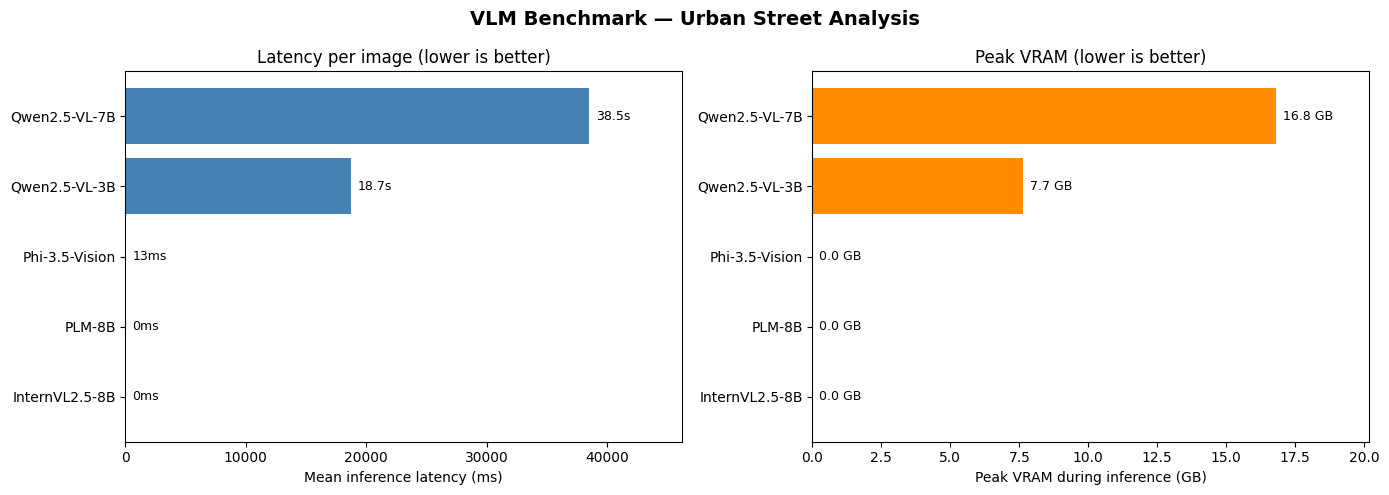

In [12]:
# ── Bar charts: Latency + Peak VRAM ──────────────────────────────────────────
num = (
    results_df.groupby("model")
    .agg(mean_latency=("latency_ms", "mean"), peak_vram=("peak_vram_gb", "max"))
    .reset_index()
)
order = num.sort_values("mean_latency")["model"].tolist()
num = num.set_index("model").loc[order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(num) * 0.8 + 1)))
fig.suptitle("VLM Benchmark — Urban Street Analysis", fontsize=14, fontweight="bold")

# Latency
bars0 = axes[0].barh(num["model"], num["mean_latency"], color="steelblue")
axes[0].set_xlabel("Mean inference latency (ms)")
axes[0].set_title("Latency per image (lower is better)")
# bar_label places text relative to bar end in points — safe regardless of data scale
axes[0].bar_label(bars0, fmt=lambda v: f"{v/1000:.1f}s" if v >= 1000 else f"{v:.0f}ms", padding=5, fontsize=9)
axes[0].margins(x=0.20)   # add right-side room for labels without stretching the canvas

# Peak VRAM
bars1 = axes[1].barh(num["model"], num["peak_vram"], color="darkorange")
axes[1].set_xlabel("Peak VRAM during inference (GB)")
axes[1].set_title("Peak VRAM (lower is better)")
axes[1].bar_label(bars1, fmt="{:.1f} GB".format, padding=5, fontsize=9)
axes[1].margins(x=0.20)

plt.tight_layout()
plt.savefig("benchmark_latency_vram.png", dpi=150)   # no bbox_inches="tight" — avoids canvas explosion
plt.show()

Saved: benchmark_field_population.csv


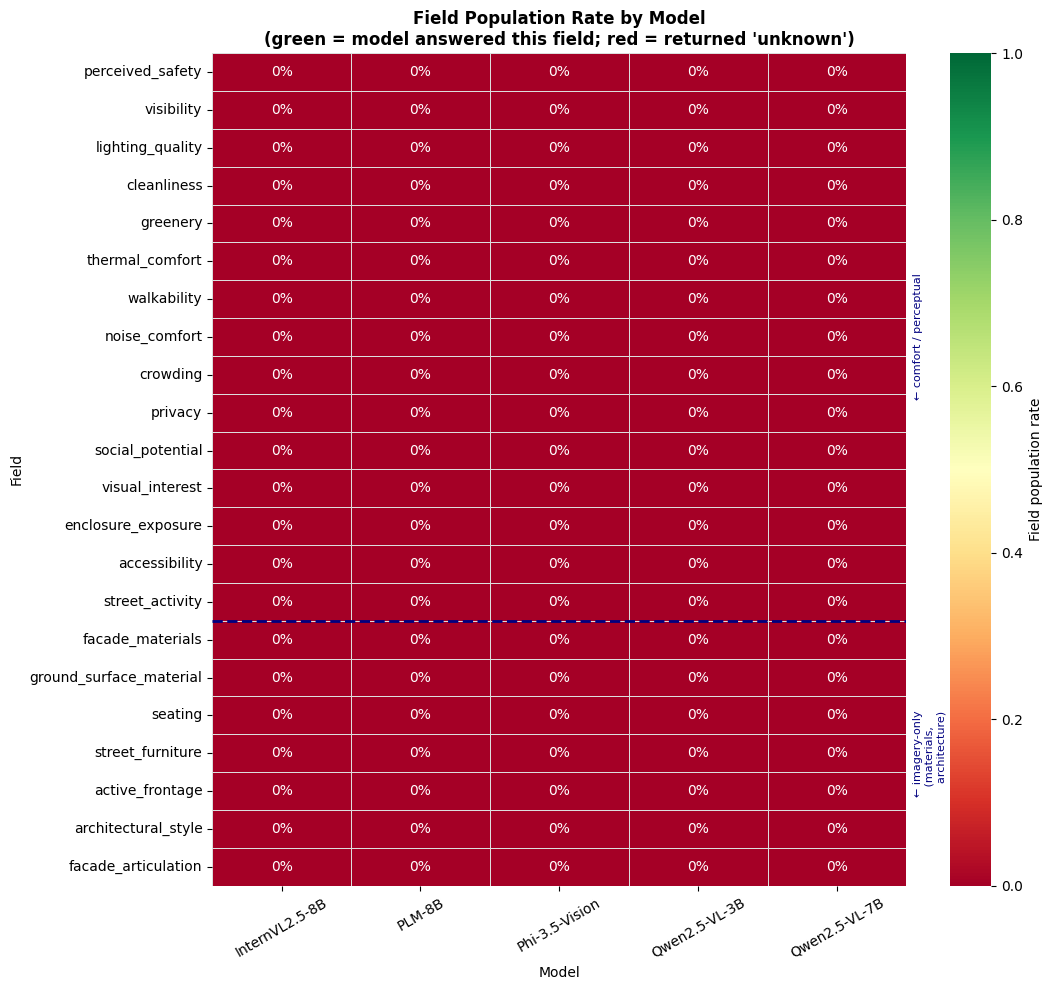

In [13]:
# ── Field population heatmap ──────────────────────────────────────────────────
# For each model + field, compute mean population rate across test images.
# "populated" = field value is not "unknown" / empty.

heat_rows = []
for _, row in results_df.iterrows():
    if not row["parse_ok"] or row["echo_detected"]:
        for f in TEXT_FIELDS:
            heat_rows.append({"model": row["model"], "field": f, "populated": 0})
        continue
    parsed, ok, echo = _parse_scene_json(row["raw_text"] if isinstance(row.get("raw_text"), str) else "{}")
    for f in TEXT_FIELDS:
        val = parsed.get(f, "unknown")
        heat_rows.append({"model": row["model"], "field": f, "populated": int(val not in ("unknown", "", None))})

heat_df = pd.DataFrame(heat_rows).groupby(["model", "field"])["populated"].mean().unstack("model")
heat_df = heat_df.reindex(TEXT_FIELDS)  # keep field order consistent

# Save field population rates as CSV
heat_df.reset_index().rename(columns={"field": "field"}).to_csv("benchmark_field_population.csv", index=False)
print("Saved: benchmark_field_population.csv")

fig, ax = plt.subplots(figsize=(max(8, len(heat_df.columns) * 2.2), 10))
sns.heatmap(
    heat_df, ax=ax, vmin=0, vmax=1, cmap="RdYlGn",
    annot=True, fmt=".0%", linewidths=0.5, linecolor="#ddd",
    cbar_kws={"label": "Field population rate"},
)
ax.set_title("Field Population Rate by Model\n(green = model answered this field; red = returned 'unknown')",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Field")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

# Horizontal separator between original 15 fields and 7 new imagery-only fields
ax.axhline(15, color="navy", linewidth=2, linestyle="--")
ax.text(len(heat_df.columns) + 0.05, 7.5, "← comfort / perceptual",
        va="center", ha="left", fontsize=8, color="navy", rotation=90)
ax.text(len(heat_df.columns) + 0.05, 18.5, "← imagery-only\n   (materials,\n    architecture)",
        va="center", ha="left", fontsize=8, color="navy", rotation=90)

plt.tight_layout()
plt.savefig("benchmark_field_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ── Side-by-side output comparison ───────────────────────────────────────────
# Shows raw model outputs for the first test image, truncated for readability.

PREVIEW_FIELDS = ["perceived_safety", "facade_materials", "architectural_style", "active_frontage"]
first_image = test_images[0][0]

print(f"\nSample outputs for: {first_image}")
print("=" * 80)

img_rows = results_df[results_df["image"] == first_image]

for _, row in img_rows.iterrows():
    print(f"\n── {row['model']} ──")
    print(f"   parse={row['parse_ok']}  echo={row['echo_detected']}  "
          f"pop={row['pop_rate']:.0%}  latency={row['latency_ms']:.0f}ms")
    if row["parse_ok"] and not row["echo_detected"] and row.get("raw_text"):
        parsed, _, _ = _parse_scene_json(row["raw_text"])
        for f in PREVIEW_FIELDS:
            val = parsed.get(f, "unknown")
            print(f"   {f:25s}: {str(val)[:120]}")
    elif row.get("error"):
        print(f"   ERROR: {row['error']}")
    else:
        print(f"   (no parseable output)")


Sample outputs for: sv_41.3952_2.1617_h0.jpg

── Qwen2.5-VL-3B ──
   parse=True  echo=False  pop=100%  latency=18657ms
   perceived_safety         : unknown
   facade_materials         : unknown
   architectural_style      : unknown
   active_frontage          : unknown

── Qwen2.5-VL-7B ──
   parse=True  echo=False  pop=100%  latency=40961ms
   perceived_safety         : unknown
   facade_materials         : unknown
   architectural_style      : unknown
   active_frontage          : unknown

── InternVL2.5-8B ──
   parse=False  echo=False  pop=0%  latency=0ms
   ERROR: Tensor.item() cannot be called on meta tensors

── PLM-8B ──
   parse=False  echo=False  pop=0%  latency=0ms
   ERROR: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

── Phi-3.5-Vision ──
   parse=False  echo

---
## Conclusions

Use the summary table and heatmap to pick the model that:
1. **Maximises field population rate** — especially for the 7 imagery-only fields below the dashed line (facade materials, architectural style, etc.)
2. **Has parse rate ≥ 90%** and echo rate ≈ 0%
3. **Fits within your VRAM budget** — peak VRAM is measured empirically here, not estimated
4. **Has acceptable latency** — multiply mean latency by number of sample points to estimate total job time

### Model status for EU deployments

| Model | Status | Notes |
|---|---|---|
| **Qwen2.5-VL-7B** | ✅ Recommended | Best JSON discipline; reliable field coverage; MIT license |
| **InternVL2.5-8B** | ✅ Strong alternative | Best fine-grained spatial + material detail; Apache 2.0 |
| **Phi-3.5-Vision** | ✅ Efficient option | Fastest; decent structured output; MIT license |
| **Qwen2.5-VL-3B** | ✅ VRAM-constrained fallback | Quality noticeably below 7B but works on 8 GB |
| **Llama-3.2-11B-Vision** | ❌ Blocked | Meta disallows downloads from EU IP addresses |

### Next step
Update `MODEL_ID` in `street_plm_job.py` to the benchmark winner.
If the winner is InternVL2.5-8B, switch the adapter class and loader accordingly — the job script currently uses `Qwen2_5_VLForConditionalGeneration`.